In [18]:
import re
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import math
import nltk

{'0-150': 6913, '151-300': 2318, '301-450': 552, '451-600': 143, '601-750': 46, '751-935': 28}


Text(0.5, 1.0, 'Word Length Distribution')

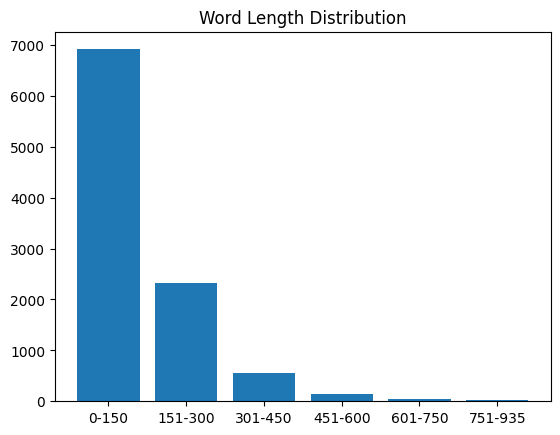

In [24]:
df = pd.read_csv('yelp.csv')
df_input = df[['text', 'stars']]
df['word_length'] = df['text'].apply(lambda x: len(x.split()))
word_ranges = {
    "0-150": 0,
    "151-300": 0,
    "301-450": 0,
    "451-600": 0,
    "601-750": 0,
    "751-935": 0,
}

for length in df['word_length']:
    if length <= 150:
        word_ranges["0-150"] += 1
    elif length <= 300:
        word_ranges["151-300"] += 1
    elif length <= 450:
        word_ranges["301-450"] += 1
    elif length <= 600:
        word_ranges["451-600"] += 1
    elif length <= 750:
        word_ranges["601-750"] += 1
    else:
        word_ranges["751-935"] += 1
print(word_ranges)

#plotting the word length distribution
plt.bar(word_ranges.keys(), word_ranges.values())
plt.title('Word Length Distribution')

{'1': 7.49, '2': 9.27, '3': 14.61, '4': 35.26, '5': 33.37}


Text(0.5, 1.0, 'Star Rating Distribution %')

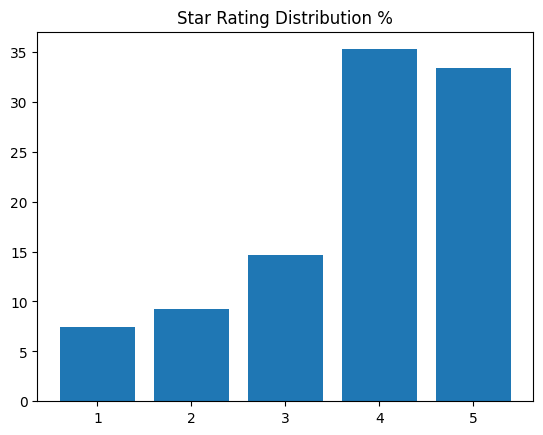

In [ ]:
stars_ranges = {
    "1": int(df['stars'].value_counts().get(1, 0))/100,
    "2": int(df['stars'].value_counts().get(2, 0))/100,
    "3": int(df['stars'].value_counts().get(3, 0))/100,
    "4": int(df['stars'].value_counts().get(4, 0))/100,
    "5": int(df['stars'].value_counts().get(5, 0))/100,
}
print(stars_ranges)

plt.bar(stars_ranges.keys(), stars_ranges.values())
plt.title('Star Rating Distribution %')

## Things to Note
Word lengths:
- Range: (1,935)
- Negatively-skewed, might be a problem
- Pad sentences and set maximum length

Star distribution:
- Positively-skewed, showing class-imbalance, deal with accordingly